In [1]:
import scanpy as sc
import pandas as pd
import os
import string
import geopandas as gpd
import numpy as np
from shapely.geometry import Point
from tqdm import tqdm
import Mapping
import matplotlib.pyplot as plt
import multiprocessing as mp
from functools import partial
import anndata
from adjustText import adjust_text
import seaborn as sns

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.stats import spearmanr

In [2]:
new_ad = sc.read_h5ad('Transciptomic_labels_and_morphology_labels_full.h5ad')

In [3]:
# first step is to find the specific genes for just microglia

ABC = sc.read_h5ad('/hpc/projects/group.quake/doug/references/ABC/whole/AIT17.0.rawcount_logCPM_10Xv3/AIT17.0.rawcount_logCPM_10Xv3.h5ad')
cl_mapping = pd.read_csv('/hpc/projects/group.quake/doug/references/ABC/AIT17.0.cl.df.v6_lock_230504/AIT17.0.cl.df.v6_lock_230504.tsv',delimiter ='\t')

subclass_map = cl_mapping.set_index('cl')['subclass_label'].to_dict()
class_map = cl_mapping.set_index('cl')['class_label'].to_dict()

ABC.obs['cl'] = ABC.obs.cl.astype(int)

ABC.obs['subclass_label'] = ABC.obs['cl'].map(subclass_map)
ABC.obs['class_label'] = ABC.obs['cl'].map(class_map)

subset_ABC = ABC[:, ABC.var_names.isin(new_ad.var_names.tolist())]

In [4]:
from scipy.sparse import issparse

def calculate_tau(adata, groupby):
    """
    Calculate Tau per gene and identify group with highest mean expression.

    Parameters:
        adata (AnnData): AnnData object subsetted to genes of interest.
        groupby (str): Column name in adata.obs to group cells by.

    Returns:
        pd.DataFrame: DataFrame with columns ['gene', 'tau', 'max_group'].
    """
    # Handle sparse/dense matrices
    X = adata.X.toarray() if issparse(adata.X) else adata.X

    # Create a DataFrame for mean expression per gene per group
    obs = adata.obs[groupby]
    df_expr = pd.DataFrame(X, index=obs, columns=adata.var_names)

    # Remove groups with no cells (important!)
    df_expr = df_expr.loc[~df_expr.index.isna()]
    
    # Mean expression per group
    mean_expr = df_expr.groupby(level=0).mean().T  # genes x groups

    # Check if mean_expr is empty
    if mean_expr.empty:
        raise ValueError("The resulting mean expression DataFrame is empty. Check your grouping labels.")

    # Identify max group and max expression per gene
    max_expr = mean_expr.max(axis=1)
    max_group = mean_expr.idxmax(axis=1)

    # Compute Tau values safely (handling division by zero)
    with np.errstate(divide='ignore', invalid='ignore'):
        tau_values = (1 - mean_expr.div(max_expr, axis=0)).sum(axis=1) / (mean_expr.shape[1] - 1)
        tau_values = tau_values.fillna(0)  # Handle genes with zero expression across all groups

    # Assemble results
    result_df = pd.DataFrame({
        'gene': mean_expr.index,
        'tau': tau_values.values,
        'max_group': max_group.values
    })

    return result_df

In [5]:
# calculate tau for two levels of celltyping
tau_df = calculate_tau(subset_ABC,'subclass_label')
tau_df_class = calculate_tau(subset_ABC,'class_label')

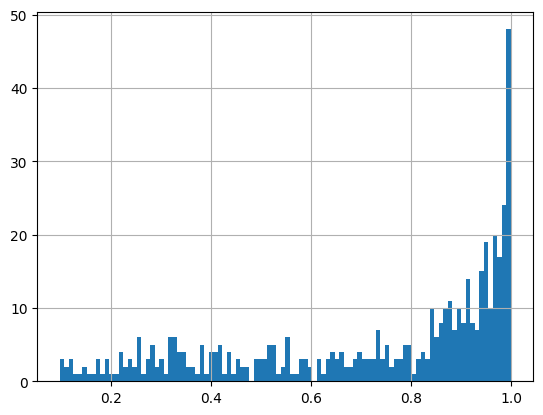

In [6]:
tau_df_class.tau.hist(bins=100)
plt.savefig('Response_document_tau_class.pdf')

In [7]:
tau_df_class[tau_df_class.gene.isin(['Slc1a2','Gria2','Ank2','Gria2','Aldoc','Slc6a11','Pcdh9'])]

,gene,tau,max_group
48,Slc1a2,0.616586,Astro-Epen
72,Gria2,0.228238,LSX GABA
79,Ank2,0.100220,NP-CT-L6b Glut
156,Slc6a11,0.787003,Astro-Epen
311,Aldoc,0.720493,Astro-Epen
378,Pcdh9,0.248576,Oligo


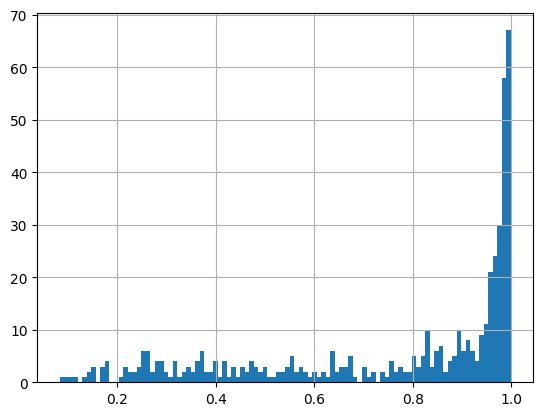

In [8]:
tau_df.tau.hist(bins=100)
plt.savefig('Response_document_tau_spec.pdf')

In [9]:
tau_df[tau_df.gene.isin(['Slc1a2','Gria2','Ank2','Gria2','Aldoc','Slc6a11','Pcdh9'])]

,gene,tau,max_group
48,Slc1a2,0.640131,Astro-TE NN
72,Gria2,0.202857,DCO UBC Glut
79,Ank2,0.259057,Bergmann NN
156,Slc6a11,0.786264,Astro-OLF NN
311,Aldoc,0.668844,Bergmann NN
378,Pcdh9,0.240237,LDT Fgf7 Gaba


In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from typing import List, Union

def plot_gene_expression_grid(adata, gene_list: List[str], figsize: tuple = (15, 15)):
    """
    Plot average gene expression for specified cell groups in a 3x3 grid.
    
    Parameters:
    -----------
    adata : AnnData object
        The scanpy anndata object containing gene expression data and metadata
    gene_list : List[str]
        List of genes to plot (maximum 9 genes)
    figsize : tuple, optional
        Figure size for the plot (default: (15, 15))
    
    Returns:
    --------
    fig, axes : matplotlib figure and axes objects
    """
    
    # Validate input
    if len(gene_list) > 9:
        raise ValueError("Maximum 9 genes allowed for 3x3 grid")
    
    # Check if genes exist in the dataset
    missing_genes = [gene for gene in gene_list if gene not in adata.var_names]
    if missing_genes:
        print(f"Warning: The following genes are not found in the dataset: {missing_genes}")
        gene_list = [gene for gene in gene_list if gene in adata.var_names]
    
    if len(gene_list) == 0:
        raise ValueError("No valid genes found in the dataset")
    
    # Define cell groups
    cell_groups = {
        'Astro-Epen': adata.obs['class_label'] == 'Astro-Epen',
        'Oligo': adata.obs['class_label'] == 'Oligo',
        'Microglia NN': adata.obs['subclass_label'] == 'Microglia NN'
    }
    
    # Check if groups exist and have cells
    for group_name, mask in cell_groups.items():
        n_cells = mask.sum()
        if n_cells == 0:
            print(f"Warning: No cells found for group '{group_name}'")
        else:
            print(f"Found {n_cells} cells for group '{group_name}'")
    
    # Create figure and subplots
    fig, axes = plt.subplots(3, 3, figsize=figsize)
    axes = axes.flatten()  # Flatten for easy indexing
    
    # Set color palette
    colors = ['#2E86AB', '#A23B72', '#F18F01']  # Blue, Purple, Orange
    group_names = list(cell_groups.keys())
    
    # Plot each gene
    for i, gene in enumerate(gene_list):
        ax = axes[i]
        
        if gene not in adata.var_names:
            ax.text(0.5, 0.5, f'Gene {gene}\nnot found', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{gene} (Not Found)')
            continue
        
        # Calculate average expression and SEM for each group
        avg_expressions = []
        sem_values = []
        group_labels = []
        
        for group_name, mask in cell_groups.items():
            if mask.sum() > 0:  # Only include groups with cells
                # Get expression data for this gene and group
                gene_idx = adata.var_names.get_loc(gene)
                group_expression = adata.X[mask, gene_idx]
                
                # Handle sparse matrices
                if hasattr(group_expression, 'toarray'):
                    group_expression = group_expression.toarray().flatten()
                else:
                    group_expression = np.array(group_expression).flatten()
                
                # Calculate mean and standard error of the mean
                avg_expr = np.mean(group_expression)
                n_cells = len(group_expression)
                std_expr = np.std(group_expression, ddof=1)  # Sample standard deviation
                sem = std_expr # / np.sqrt(n_cells) if n_cells > 1 else 0
                
                avg_expressions.append(avg_expr)
                sem_values.append(sem)
                group_labels.append(group_name)
        
        # Create bar plot with error bars
        if avg_expressions:
            bars = ax.bar(range(len(group_labels)), avg_expressions, 
                         yerr=sem_values, capsize=5,
                         color=colors[:len(group_labels)], alpha=0.7, 
                         edgecolor='black', ecolor='black', linewidth=1.5)
            
            # Customize subplot
            ax.set_xlabel('Cell Groups')
            ax.set_ylabel('Average Log Expression')
            ax.set_title(f'{gene}', fontsize=14, fontweight='bold')
            ax.set_xticks(range(len(group_labels)))
            ax.set_xticklabels(group_labels, rotation=45, ha='right')
            
            # Add grid for better readability
            ax.grid(True, alpha=0.3, axis='y')
            ax.set_axisbelow(True)
        else:
            ax.text(0.5, 0.5, f'No data available\nfor {gene}', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{gene} (No Data)')
    
    # Hide empty subplots
    for i in range(len(gene_list), 9):
        axes[i].set_visible(False)
    
    # Adjust layout
    plt.tight_layout(pad=3.0)
    
    # Add overall title
    #fig.suptitle('Average Gene Expression by Cell Type', 
    #             fontsize=16, fontweight='bold', y=0.98)
    
    return fig, axes

Found 297204 cells for group 'Astro-Epen'
Found 479086 cells for group 'Oligo'
Found 81628 cells for group 'Microglia NN'


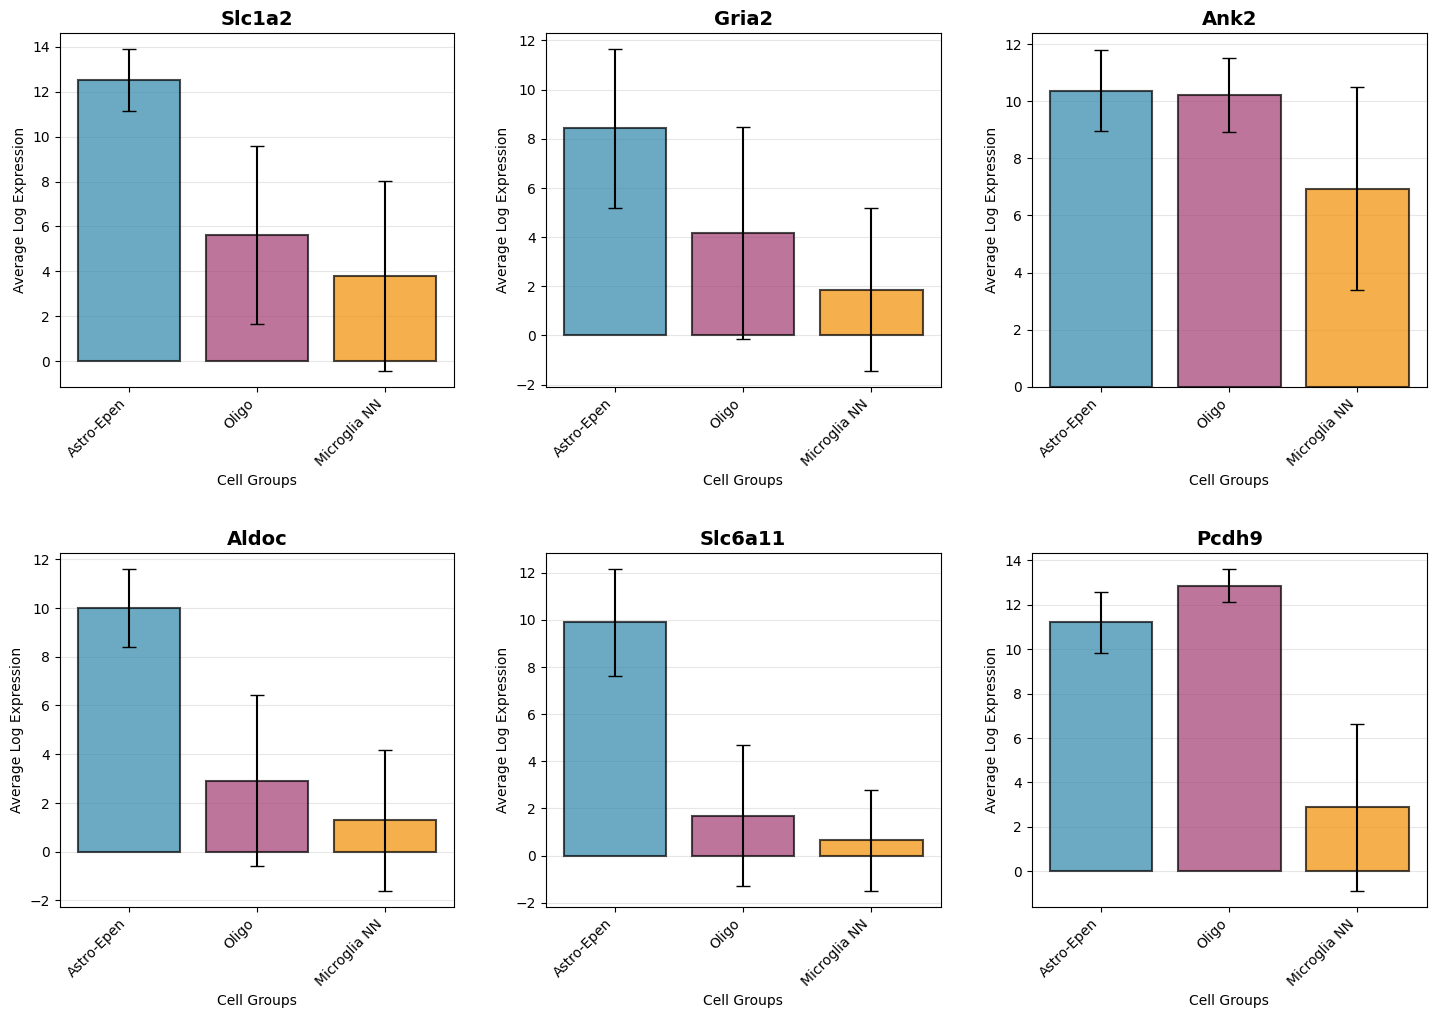

In [11]:
fig, axes = plot_gene_expression_grid(subset_ABC, ['Slc1a2','Gria2','Ank2','Aldoc','Slc6a11','Pcdh9'])
plt.savefig('Response_document_expression.pdf')
plt.show()